In [1]:
import numpy as np
import tqdm
import re
import ipywidgets
import matplotlib.pyplot as plt
from scipy.constants import k, e
from scipy.interpolate import RegularGridInterpolator
import sys
sys.path.append('../../sedov_theory/python/')
from sedov_theory import SedovTalorProblem
import yt
from analysis_tool import CastroSimulation

In [2]:
run_dir = '../run/'
file_start = 'plt_1d_'

In [3]:
cs = CastroSimulation(run_dir, file_start)

100%|█████████████████████████████████████████| 307/307 [00:03<00:00, 89.97it/s]


# Compare data with theory

In [4]:
# Calculate analytical solution
gamma = 5./3
rho = 3.24e-6 # g / cm^3
E = 90 # erg / cm

sol = SedovTalorProblem(gamma, E, rho)

In [5]:
import skimage
import matplotlib.pyplot as plt

In [17]:
filename = '/Users/rlehe/Downloads/HTT_nepng/Scan027_HTT_nex1e17png_105hydrotime6.0ns.png'
time = float(re.findall('hydrotime([\d\.]+)', filename)[0])*1e-9
data = skimage.io.imread(filename)
r, q, t = cs.extract_data( time, 'density', level=3)

Text(0.5, 1.0, 't = 6.0 ns')

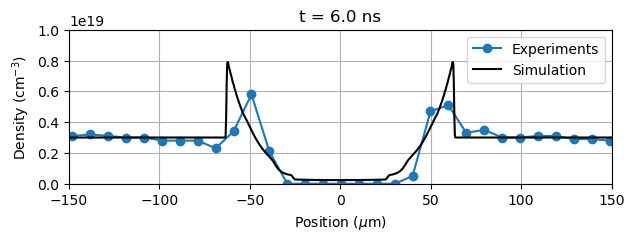

In [18]:
plt.figure(figsize=(7, 2))

x = 9.9*np.arange(data.shape[1])
plt.plot( x-0.455*1e3, data[16]*1.e17, '-o', label='Experiments' )
plt.plot( r*1e4, q*1e18/1.67e-6, 'k-', label='Simulation' )
plt.plot( -r*1e4, q*1e18/1.67e-6, 'k-' )
plt.grid()
plt.legend(loc=0)
plt.ylabel('Density (cm$^{-3}$)')
plt.xlabel('Position ($\mu$m)')
plt.xlim(-150, 150)
plt.ylim(0, 10e18)
plt.title('t = %.1f ns' %(time*1.e9))